In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')


In [2]:
data={
    "CustomerID":np.arange(1,101),
    "Age":np.random.randint(18,65,size=100),
    "Average_Spend":np.random.uniform(5,50,size=100),
    "Visits_per_Month":np.random.uniform(1,7,size=100),
    "Promotion_Interest":np.random.randint(1,11,size=100)
}
df=pd.DataFrame(data)
df

,CustomerID,Age,Average_Spend,Visits_per_Month,Promotion_Interest
0,1,28,16.929456,4.925084,5
1,2,29,23.525648,2.335714,2
2,3,61,41.419129,4.139556,3
3,4,48,37.375093,3.088713,10
4,5,47,13.223071,2.675998,9
...,...,...,...,...,...
95,96,46,38.372153,3.625787,2
96,97,25,33.024225,2.757467,10
97,98,62,26.104558,1.833254,5
98,99,20,36.898588,1.557746,8


In [3]:
X=df[["Age","Average_Spend","Visits_per_Month","Promotion_Interest"]]
sse=[]
k_range=range(1,11)
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)
print("SSE for different k values:", sse)

SSE for different k values: [36076.81069248444, 21344.19666654481, 13920.161735993639, 11054.268356239114, 8552.703132641675, 7158.568566348014, 6118.944099894063, 5334.9905955636, 5131.550587554762, 4430.142999490538]


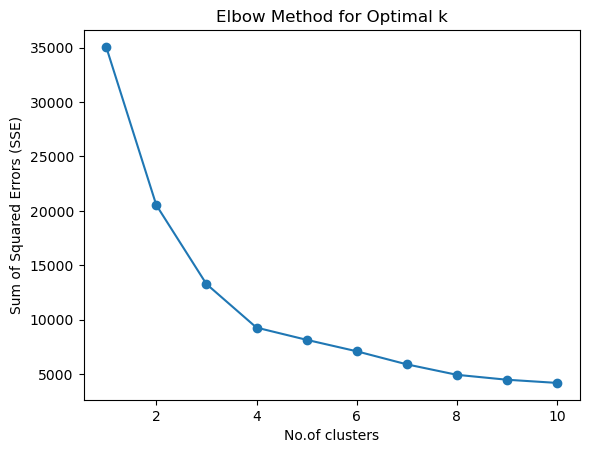

In [6]:
plt.plot(k_range,sse,marker='o')
plt.xlabel("No.of clusters")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method for Optimal k")
plt.show()

In [4]:
features=df[["Age","Average_Spend","Visits_per_Month","Promotion_Interest"]]
kmeans=KMeans(n_clusters=3,random_state=42)
df['Cluster']=kmeans.fit_predict(features)
cluster_names={0:'Daily',1:'Promotion',2:'Weekend'}
df['Cluster Group']=df['Cluster'].map(cluster_names)
df.head()

,CustomerID,Age,Average_Spend,Visits_per_Month,Promotion_Interest,Cluster,Cluster Group
0,1,28,16.929456,4.925084,5,1,Promotion
1,2,29,23.525648,2.335714,2,2,Weekend
2,3,61,41.419129,4.139556,3,0,Daily
3,4,48,37.375093,3.088713,10,0,Daily
4,5,47,13.223071,2.675998,9,1,Promotion


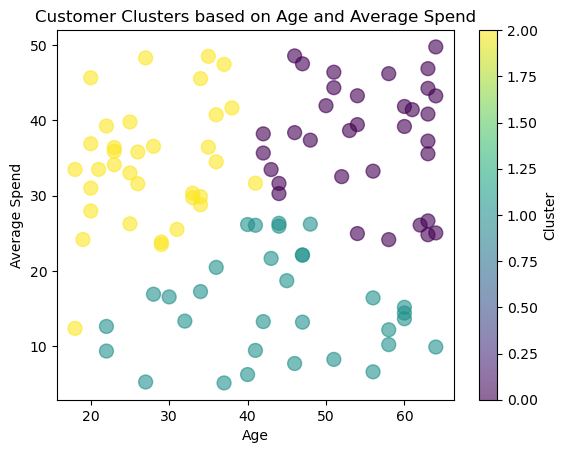

In [5]:
plt.scatter(df['Age'], df['Average_Spend'], c=df['Cluster'], cmap='viridis', marker='o', s=100, alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Average Spend')
plt.title('Customer Clusters based on Age and Average Spend')
plt.colorbar(label='Cluster')
plt.show()

In [6]:

# Using silhouette score (measures how similar a point is to its own cluster compared to other clusters)
silhouette_avg = silhouette_score(features, df['Cluster'])
print(f'Silhouette Score: {silhouette_avg:.2f}')

Silhouette Score: 0.37


In [7]:

import pickle

pickle.dump(kmeans,open("kmeans.pkl",'wb'))

In [8]:
kmeans = pickle.load(open("kmeans.pkl",'rb'))

In [9]:
# For a new customer with Age=40, Average_Spend=$30, Visits_per_Week=4, Promotion_Interest=7

def clustering(age,avg_spend,visit_per_week, promotion_interest):
    new_customer = np.array([[age,avg_spend,visit_per_week, promotion_interest]])
    predicted_cluster = kmeans.predict(new_customer)
    
    if predicted_cluster[0]==0:
        return "Daily"
    elif predicted_cluster[0]==1:
        return "Weekend"
    else:
        return "Promotion"

In [10]:
age = 40
avg_spend = 30
visit_per_week= 4
promotion_interest= 7


predicted_cluster = clustering(age, avg_spend,visit_per_week,promotion_interest)
print(f'New Customer assigned to Cluster: {predicted_cluster}')

# Save the generated dataset as CSV
df.to_csv('customer_clusters.csv', index=False)

New Customer assigned to Cluster: Promotion


In [11]:
age = 40
avg_spend = 10
visit_per_week= 1
promotion_interest= 0


predicted_cluster = clustering(age, avg_spend,visit_per_week,promotion_interest)
print(f'New Customer assigned to Cluster: {predicted_cluster}')

# Save the generated dataset as CSV
df.to_csv('customer_clusters.csv', index=False)

New Customer assigned to Cluster: Weekend
